# 01 — Dataset Inspection

Explore the Levine32 CyTOF dataset: marker distributions, label counts, correlation heatmap.

**Loading priority:**
1. Pre-processed file `data/levine32_processed.h5ad` (fastest — run `prepare_data.py` once).
2. Raw load via **PyCytoData** → preprocess on the fly (requires `pip install PyCytoData`).

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path('..').resolve()   # MambaC2S/
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.loader import load_levine32, load_processed
from src.data.preprocessing import preprocess_from_config
from src.utils.config import load_config

%matplotlib inline
plt.rcParams['figure.dpi'] = 100
print('Project root:', PROJECT_ROOT)

Project root: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/MambaC2S


In [2]:
cfg = load_config(PROJECT_ROOT / 'configs' / 'base.yaml')

DATA_DIR     = PROJECT_ROOT / cfg['dataset']['data_dir']
DATASET_NAME = cfg['dataset']['dataset_name']
LABEL_COL    = cfg['dataset']['label_col']
PREP_CFG     = cfg['preprocessing']

print(f'Data directory : {DATA_DIR}')
print(f'Dataset        : {DATASET_NAME}')

Data directory : /Users/ronguy/Dropbox/Work/CyTOF/Experiments/MambaC2S/data
Dataset        : levine32


## Load Data

In [3]:
processed_path = DATA_DIR / f'{DATASET_NAME}_processed.h5ad'

if processed_path.exists():
    print(f'Loading pre-processed data from {processed_path} ...')
    df = load_processed(processed_path, label_col=LABEL_COL)
else:
    print('Pre-processed file not found — loading via PyCytoData and preprocessing on the fly ...')
    print('(Run scripts/prepare_data.py to cache the processed file for faster future loads.)')
    df_raw = load_levine32(force_download=True)
    df, _  = preprocess_from_config(df_raw, PREP_CFG)

print(f'\nShape  : {df.shape}')
print(f'Columns: {list(df.columns[:8])} ...')
df.head(3)

Pre-processed file not found — loading via PyCytoData and preprocessing on the fly ...
(Run scripts/prepare_data.py to cache the processed file for faster future loads.)


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/PyCytoData/data.py:15: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/fcsparser/api.py:490: UserWarning: The default channel names (defined by the $PnS parameter in the FCS file) were not unique. To avoid problems in downstream analysis, the channel names have been switched to the alternate channel names defined in the FCS file. To avoid seeing this warning message, explicitly instruct the FCS parser to use the alternate channel names by specifying the channel_naming parameter.
  warnings.warn(msg)



Shape  : (265627, 98)
Columns: ['cell_id', 'CD45RA', 'CD133', 'CD19', 'CD22', 'CD11b', 'CD4', 'CD8'] ...


,cell_id,CD45RA,CD133,CD19,CD22,CD11b,CD4,CD8,CD34,Flt3,...,CD44_bin,CD38_bin,CD13_bin,CD3_bin,CD61_bin,CD117_bin,CD49d_bin,HLA-DR_bin,CD64_bin,CD41_bin
0,cell_0,-0.862639,-0.677085,-0.601774,-0.434227,-0.711371,-0.007722,-0.044861,-0.530266,0.323234,...,LOW,MED,LOW,LOW,LOW,MED,MED,MED,LOW,MED
1,cell_1,0.021706,-0.710621,-0.613387,-0.423702,0.096608,-0.778973,-0.573653,-0.376504,9.557900,...,MED,HIGH,HIGH,LOW,HIGH,HIGH,LOW,MED,MED,HIGH
2,cell_2,-0.138826,-0.687231,-0.507832,-0.577727,-0.704150,-0.727475,-0.568752,-0.554188,-0.614153,...,MED,MED,MED,MED,MED,MED,HIGH,MED,LOW,MED


## Identify Marker Columns

The preprocessed DataFrame also contains `{marker}_rank` and `{marker}_bin` columns — we keep only the base names for plotting.

In [4]:
non_marker = {LABEL_COL, 'cell_id'}
marker_cols = [
    c for c in df.columns
    if c not in non_marker
    and not c.endswith('_rank')
    and not c.endswith('_bin')
]
print(f'Markers ({len(marker_cols)}): {marker_cols}')

Markers (32): ['CD45RA', 'CD133', 'CD19', 'CD22', 'CD11b', 'CD4', 'CD8', 'CD34', 'Flt3', 'CD20', 'CXCR4', 'CD235ab', 'CD45', 'CD123', 'CD321', 'CD14', 'CD33', 'CD47', 'CD11c', 'CD7', 'CD15', 'CD16', 'CD44', 'CD38', 'CD13', 'CD3', 'CD61', 'CD117', 'CD49d', 'HLA-DR', 'CD64', 'CD41']


## Label Distribution

In [5]:
labeled   = df[df[LABEL_COL].notna()]
unlabeled = df[df[LABEL_COL].isna()]

print(f'Labeled cells   : {len(labeled):>8,}')
print(f'Unlabeled cells : {len(unlabeled):>8,}')
print(f'Total           : {len(df):>8,}')

counts = labeled[LABEL_COL].value_counts()
print(f'\nCell types ({len(counts)}):')
print(counts.to_string())

Labeled cells   :  104,184
Unlabeled cells :  161,443
Total           :  265,627

Cell types (14):
label
CD4_T_cells               26366
Monocytes                 21099
CD8_T_cells               20108
Mature_B_cells            16520
Pre_B_cells                6135
CD16-_NK_cells             3905
CD34+CD38+CD123-_HSPCs     3295
CD16+_NK_cells             2248
pDCs                       1238
Basophils                  1207
CD34+CD38lo_HSCs            916
Pro_B_cells                 513
Plasma_B_cells              330
CD34+CD38+CD123+_HSPCs      304


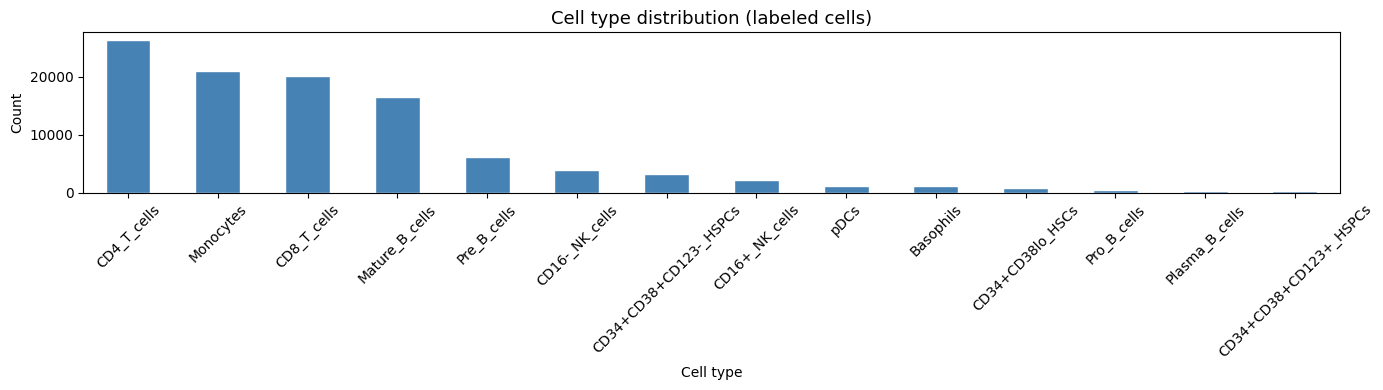

In [6]:
fig, ax = plt.subplots(figsize=(14, 4))
counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Cell type distribution (labeled cells)', fontsize=13)
ax.set_xlabel('Cell type')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## Marker Distributions

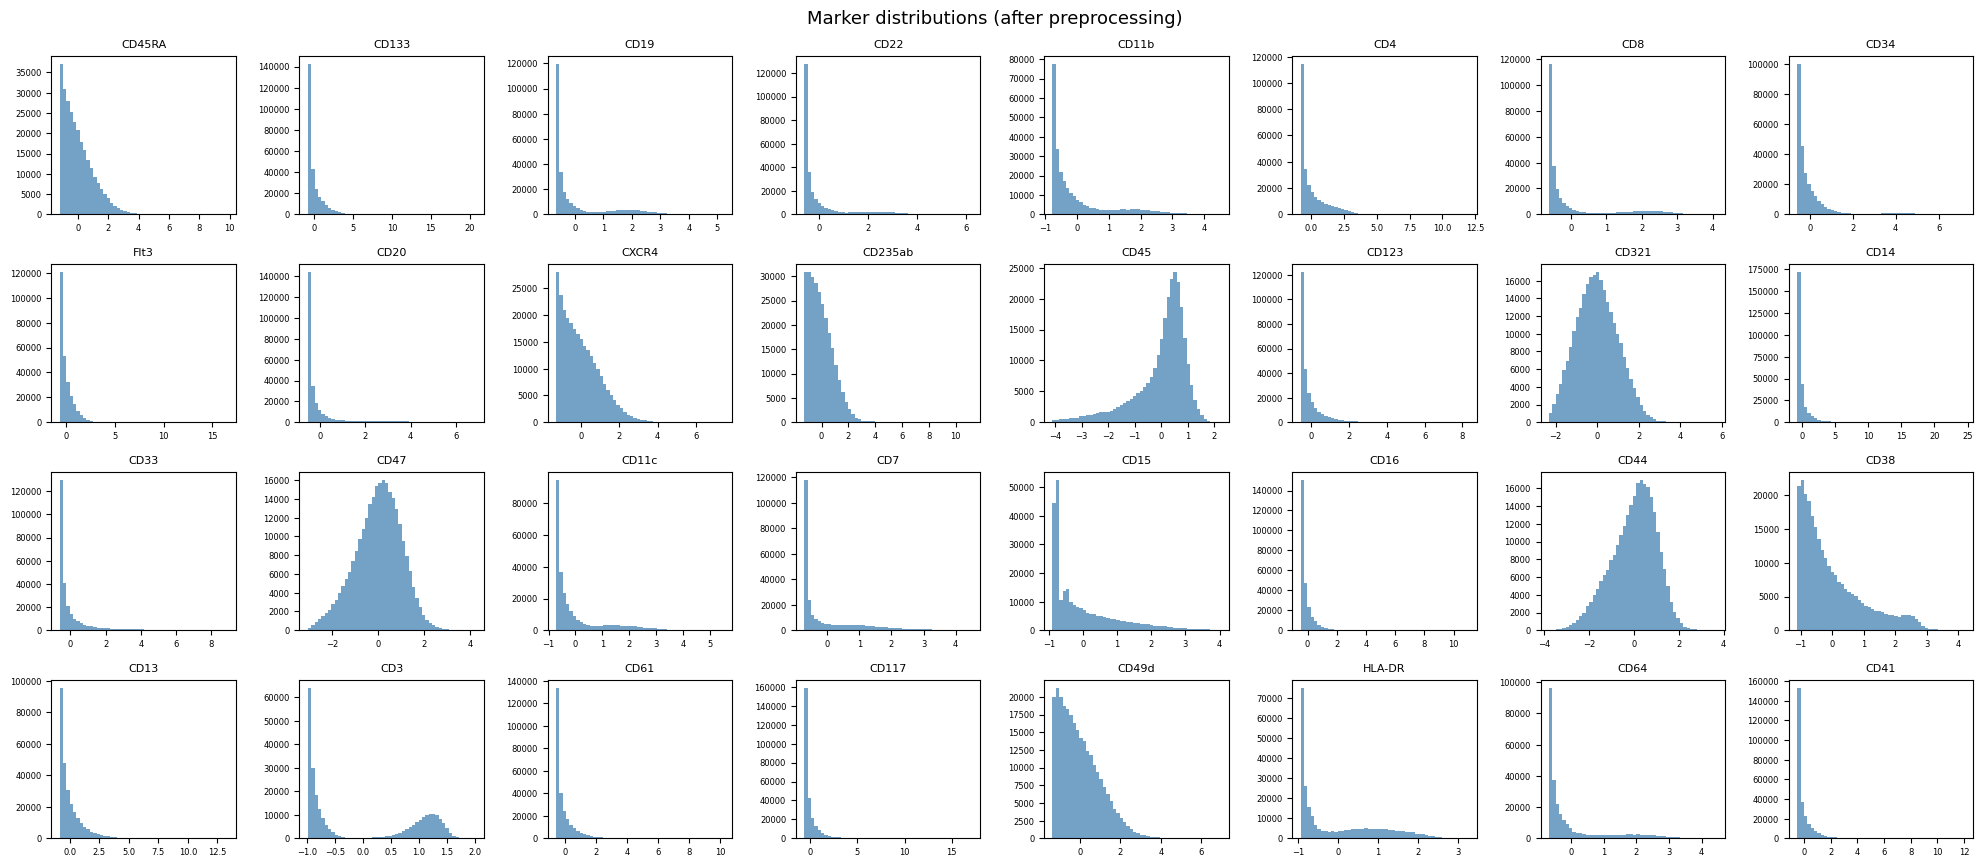

In [7]:
n = len(marker_cols)
ncols = min(8, n)
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 2.5, nrows * 2.2))
axes_flat = axes.flatten() if hasattr(axes, 'flatten') else [axes]

for i, marker in enumerate(marker_cols):
    axes_flat[i].hist(df[marker].dropna(), bins=50, color='steelblue', alpha=0.75)
    axes_flat[i].set_title(marker, fontsize=8)
    axes_flat[i].tick_params(labelsize=6)

for j in range(n, len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle('Marker distributions (after preprocessing)', fontsize=13)
plt.tight_layout()
plt.show()

## Marker Correlation Heatmap

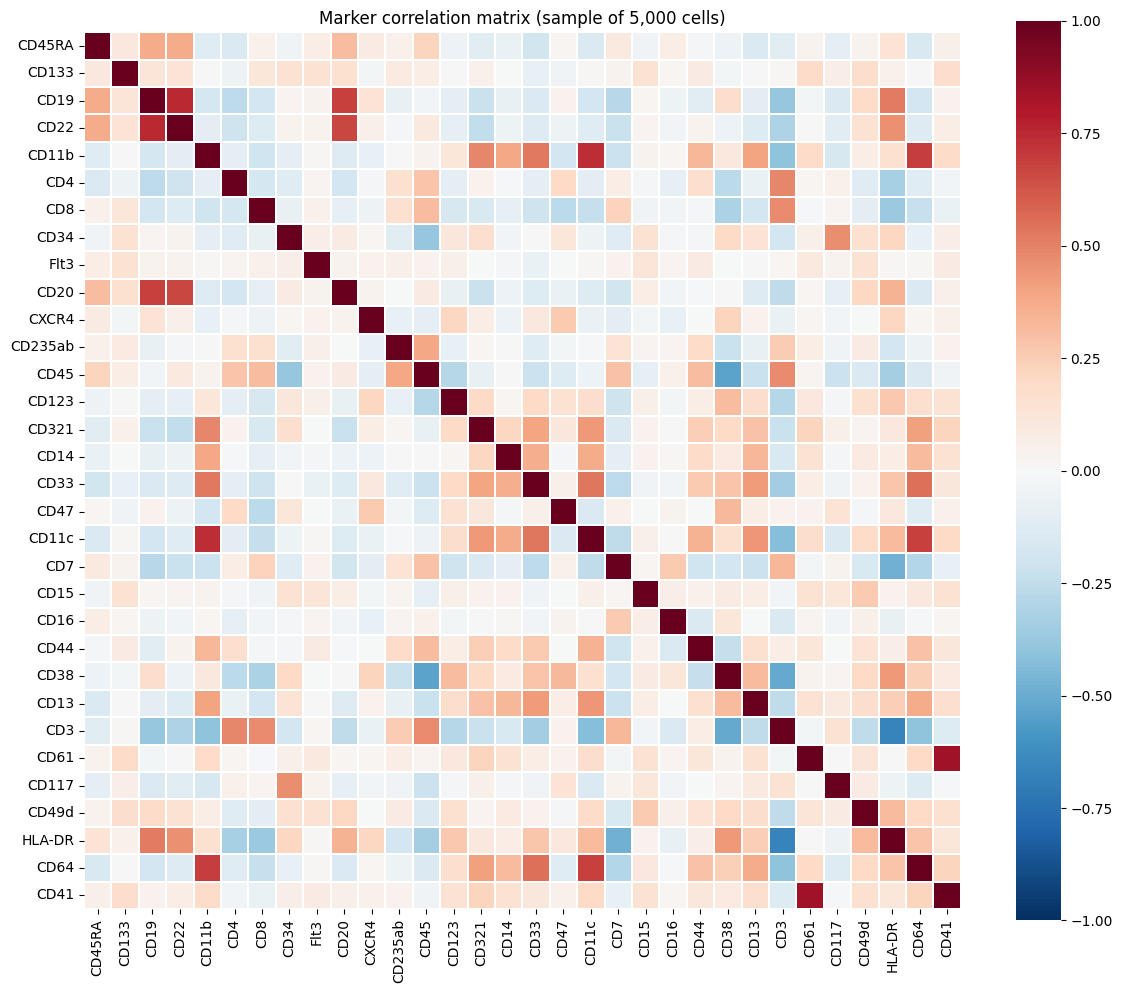

In [8]:
sample = df[marker_cols].sample(min(5000, len(df)), random_state=42)
corr   = sample.corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, ax=ax, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.3,
            annot=(n <= 20), fmt='.2f', annot_kws={'size': 7})
ax.set_title('Marker correlation matrix (sample of 5,000 cells)')
plt.tight_layout()
plt.show()

## Bin Distribution Check

Verify that the strength bins (LOW/MED/HIGH) are roughly balanced across markers.

In [9]:
bin_cols = [f'{m}_bin' for m in marker_cols if f'{m}_bin' in df.columns]
if bin_cols:
    # Show bin counts for first marker as a sanity check
    example_bin_col = bin_cols[0]
    print(f'Bin distribution for {example_bin_col.replace("_bin", "")}:')
    print(df[example_bin_col].value_counts().sort_index())
    print('\n(Bins are quantile-based, so counts should be roughly equal.)')
else:
    print('No _bin columns found — run preprocessing first.')

Bin distribution for CD45RA:
CD45RA_bin
HIGH    88541
LOW     88544
MED     88542
Name: count, dtype: int64

(Bins are quantile-based, so counts should be roughly equal.)
